# Import Module & Library

In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.svm import SVC, LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectFromModel
from sklearn.preprocessing import MinMaxScaler, StandardScaler, OneHotEncoder, OrdinalEncoder, FunctionTransformer
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score, f1_score  



## Load Dataset

In [2]:
data_path = os.path.join("../../Data/Telco_Customer_Churn_Cleaned.csv")

try:
    df = pd.read_csv(data_path, sep=';')
    print(f"Data Shape: {df.shape}")
except Exception as e:
    print(f"Error: {e}")

df.head()

Data Shape: (7032, 20)


,customerID,gender,SeniorCitizen,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,FamilyStatus
0,7590-VHVEG,Female,0,1,No,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,Couple
1,5575-GNVDE,Male,0,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No,Single
2,3668-QPYBK,Male,0,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,Single
3,7795-CFOCW,Male,0,45,No,No,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,Single
4,9237-HQITU,Female,0,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,Single


# Data Transformation and Standarization

## Drop unnecesary feature 

In [3]:
df_work = df.copy()
drop_cols = ["customerID", "gender", "TotalCharges"]
drop_cols = [c for c in drop_cols if c in df_work.columns]
df_work = df_work.drop(columns=drop_cols)

## Copy and Drop curn

In [4]:
if "Churn" in df_work.columns:
    y = (
        df_work["Churn"]
        .astype(str)
        .str.strip()
        .map({"No": 0, "Yes": 1})
        )
    X = df_work.drop(columns=["Churn"])
else:
    X = df_work.copy()

print(y.value_counts(dropna=False))

Churn
0    5163
1    1869
Name: count, dtype: int64


## Transfroming tenure data

In [5]:
for c in X.select_dtypes(include="object").columns:
    X[c] = X[c].astype(str).str.strip()

def tenure_to_segment(col):
    if isinstance(col, pd.DataFrame):
        s = col.iloc[:, 0]
    else:
        s = pd.Series(col.ravel())

    s = pd.to_numeric(s, errors="coerce").fillna(0)

    bins = [-np.inf, 12, 24, 48, np.inf]
    labels = ['New Customer', "Regular Customer", "Loyal Customer", "Very Loyal"]

    seg = pd.cut(s, bins=bins, labels=labels, include_lowest=True)
    return pd.DataFrame({"tenure": seg.astype(str)})

C:\Users\alamS\AppData\Local\Temp\ipykernel_15100\2025098806.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for c in X.select_dtypes(include="object").columns:


## Build transform & encode pipe

In [6]:
# Normalisasi nilai layanan agar kolom biner tetap benar-benar Yes/No
replace_no_service_cols = [
    "MultipleLines", "OnlineSecurity", "OnlineBackup",
    "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"
]
for col in replace_no_service_cols:
    if col in X.columns:
        X[col] = X[col].replace({
            "No internet service": "No",
            "No phone service": "No"
        })

# Tenure -> segment -> ordinal
tenure_pipe = Pipeline(steps=[
    ("bucket", FunctionTransformer(
        tenure_to_segment,
        validate=False,
        feature_names_out="one-to-one"
    )),
    ("ord", OrdinalEncoder(
        categories=[["New Customer", "Regular Customer", "Loyal Customer", "Very Loyal"]],
        handle_unknown="use_encoded_value",
        unknown_value=-1
    ))
])

# Contract ordinal
contract_pipe = OrdinalEncoder(
    categories=[["Month-to-month", "One year", "Two year"]],
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

# Pisahkan kolom kategorikal: biner vs non-biner
cat_cols = X.select_dtypes(include="object").columns.tolist()

binary_yesno_cols = []
multiclass_nominal_cols = []

for col in cat_cols:
    if col == "Contract":
        continue
    uniq = set(X[col].dropna().astype(str).str.strip().str.lower().unique())
    if uniq.issubset({"yes", "no"}):
        binary_yesno_cols.append(col)
    else:
        multiclass_nominal_cols.append(col)

print("Binary map (Yes/No -> 0/1):", binary_yesno_cols)
print("OHE multiclass:", multiclass_nominal_cols)

# Mapper untuk kolom biner (tetap 1 kolom per fitur)
def map_yes_no_block(df_part):
    out = df_part.copy()
    for c in out.columns:
        out[c] = (
            out[c]
            .astype(str)
            .str.strip()
            .str.lower()
            .map({"no": 0.0, "yes": 1.0})
        )
    return out

binary_pipe = Pipeline(steps=[
    ("yn_map", FunctionTransformer(
        map_yes_no_block,
        validate=False,
        feature_names_out="one-to-one"
    ))
])

# Numeric selain tenure
num_cols = X.select_dtypes(include=np.number).columns.tolist()
num_cols = [c for c in num_cols if c != "tenure"]

# Build ColumnTransformer dinamis
transformers = [
    ("tenure_ord", tenure_pipe, ["tenure"]),
    ("contract_ord", contract_pipe, ["Contract"]),
]

if binary_yesno_cols:
    transformers.append(("bin_map", binary_pipe, binary_yesno_cols))

if multiclass_nominal_cols:
    transformers.append((
        "cat_ohe",
        OneHotEncoder(handle_unknown="ignore", sparse_output=False),
        multiclass_nominal_cols
    ))

if num_cols:
    transformers.append(("num", "passthrough", num_cols))

transform_pipeline = ColumnTransformer(
    transformers=transformers,
    remainder="drop",
    verbose_feature_names_out=False
)



Binary map (Yes/No -> 0/1): ['PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling']
OHE multiclass: ['InternetService', 'PaymentMethod', 'FamilyStatus']


C:\Users\alamS\AppData\Local\Temp\ipykernel_15100\3363484652.py:35: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include="object").columns.tolist()


## Encoding results

In [8]:
X_encoded = transform_pipeline.fit_transform(X)
encoded_cols = transform_pipeline.get_feature_names_out()
X_encoded_df = pd.DataFrame(X_encoded, columns=encoded_cols, index=X.index)

X_encoded_df.head(50)


,tenure,Contract,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,...,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,FamilyStatus_Couple,FamilyStatus_Family,FamilyStatus_Single,FamilyStatus_Single Parent,SeniorCitizen,MonthlyCharges
0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,29.85
1,2.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,56.95
2,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,53.85
3,2.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,42.30
4,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,70.70
5,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,99.65
6,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,89.10
7,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,29.75
8,2.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,104.80
9,3.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,56.15


# Feature Selections

## Split the data

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

## Define the feature selection params

In [9]:


l1_selector_estimator_v2 = LinearSVC(
    penalty="l1",
    loss="squared_hinge",
    dual=False,
    tol=1e-4,
    C=0.1,
    max_iter=5000,
    fit_intercept=True,
    class_weight="balanced",
    random_state=42
)

# Balancer data

In [10]:
n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()

# "SPW-style" untuk kelas positif (1)
# Jika kelas 1 minoritas -> >1, jika mayoritas -> <1
spw = n_neg / n_pos

class_weight_svc = {
    0: 1.0,
    1: float(spw)
}

print("n_neg:", n_neg, "n_pos:", n_pos, "spw:", round(spw, 4))
print("class_weight:", class_weight_svc)
cw_tuned = {0: 1.0, 1: class_weight_svc[1] * 0.5}

n_neg: 4130 n_pos: 1495 spw: 2.7625
class_weight: {0: 1.0, 1: 2.762541806020067}


# Model Parameter

In [11]:
Model = SVC(
    kernel="rbf", 
    C=0.5, 
    gamma=0.001, 
    probability=True, 
    random_state=42,
    class_weight=cw_tuned,
)

## Full selection pipeline

In [12]:
#svc_fs_pipeline_v1 = Pipeline(steps=[
##    ("prep", transform_pipeline),
#    ("scale", StandardScaler()),
#    ("fs", SelectFromModel(estimator=l1_selector_estimator_v1, threshold="median")),
#    ("clf", SVC(kernel="rbf", C=1.0, gamma="scale", probability=True, random_state=42))
#])

svc_fs_pipeline_v2 = Pipeline(steps=[
    ("prep", transform_pipeline),
    ("scale", StandardScaler()),
    ("fs", SelectFromModel(estimator=l1_selector_estimator_v2, threshold="0.5*median")),
    ("clf", Model)
])



## Show Feature

In [30]:
feature_names_v2 = svc_fs_pipeline_v2.named_steps["prep"].get_feature_names_out()
mask_v2 = svc_fs_pipeline_v2.named_steps["fs"].get_support()

selected_features_v2 = pd.Index(feature_names_v2)[mask_v2]
print("Jumlah fitur sebelum:", len(feature_names_v2))
print("Jumlah fitur terpilih:", len(selected_features_v2))
selected_features_v2

ValueError: when `importance_getter=='auto'`, the underlying estimator LinearSVC should have `coef_` or `feature_importances_` attribute. Either pass a fitted estimator to feature selector or call fit before calling transform.

# Training Model

In [13]:
svc_fs_pipeline_v2.fit(X_train, y_train)

y_pred = svc_fs_pipeline_v2.predict(X_test)
y_prob = svc_fs_pipeline_v2.predict_proba(X_test)[:, 1]

## Evaluation Model

In [14]:
print("Accuracy :", round(accuracy_score(y_test, y_pred), 4))
print("F1-score :", round(f1_score(y_test, y_pred), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob), 4))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy : 0.7918
F1-score : 0.6129
ROC-AUC  : 0.8283

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.85      0.86      1033
           1       0.61      0.62      0.61       374

    accuracy                           0.79      1407
   macro avg       0.73      0.74      0.74      1407
weighted avg       0.79      0.79      0.79      1407

Confusion Matrix:
 [[882 151]
 [142 232]]



Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.85      0.86      1033
           1       0.61      0.62      0.61       374

    accuracy                           0.79      1407
   macro avg       0.73      0.74      0.74      1407
weighted avg       0.79      0.79      0.79      1407

Confusion Matrix:
 [[882 151]
 [142 232]]


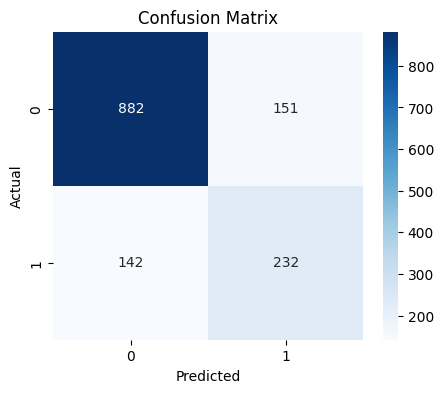

In [15]:
print("\nClassification Report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# Visual confusion matrix
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [16]:
# Predict ulang agar konsisten
y_pred = svc_fs_pipeline_v2.predict(X_test)
y_prob = svc_fs_pipeline_v2.predict_proba(X_test)[:, 1]

# Satukan hasil evaluasi per baris data test
hasil_eval = pd.DataFrame({
    "actual_num": y_test.values,
    "pred_num": y_pred,
    "prob_churn": y_prob
}, index=y_test.index)

# Ubah ke label supaya lebih mudah dibaca
label_map = {0: "No Churn", 1: "Churn"}
hasil_eval["actual_label"] = hasil_eval["actual_num"].map(label_map)
hasil_eval["pred_label"] = hasil_eval["pred_num"].map(label_map)

# Benar / Salah
hasil_eval["is_correct"] = hasil_eval["actual_num"] == hasil_eval["pred_num"]

# Urutkan kolom
hasil_eval = hasil_eval[[
    "actual_label", "pred_label", "is_correct", "prob_churn", "actual_num", "pred_num"
]]

# Lihat 20 baris pertama
hasil_eval.head(20)

,actual_label,pred_label,is_correct,prob_churn,actual_num,pred_num
971,No Churn,No Churn,True,0.026560,0,0
618,No Churn,Churn,False,0.562659,0,1
4282,No Churn,No Churn,True,0.015125,0,0
3715,Churn,No Churn,False,0.133975,1,0
4525,No Churn,No Churn,True,0.143617,0,0
445,Churn,Churn,True,0.447953,1,1
5889,No Churn,No Churn,True,0.034876,0,0
3381,No Churn,No Churn,True,0.133975,0,0
1341,Churn,Churn,True,0.678976,1,1
5681,No Churn,No Churn,True,0.035759,0,0


In [17]:
hasil_eval[hasil_eval["is_correct"] == False].head(20)

,actual_label,pred_label,is_correct,prob_churn,actual_num,pred_num
618,No Churn,Churn,False,0.562659,0,1
3715,Churn,No Churn,False,0.133975,1,0
4276,No Churn,Churn,False,0.807816,0,1
6119,No Churn,Churn,False,0.698115,0,1
4645,Churn,No Churn,False,0.105651,1,0
2295,Churn,No Churn,False,0.164012,1,0
975,Churn,No Churn,False,0.408298,1,0
2963,No Churn,Churn,False,0.648882,0,1
5729,Churn,No Churn,False,0.133975,1,0
6315,No Churn,Churn,False,0.614694,0,1


In [18]:

total_test = len(y_test)
n_benar = (y_test.values == y_pred).sum()
n_salah = total_test - n_benar

pct_benar = (n_benar / total_test) * 100
pct_salah = (n_salah / total_test) * 100

print("Total data testing:", total_test)
print("Prediksi benar:", n_benar, f"({pct_benar:.2f}%)")
print("Prediksi salah:", n_salah, f"({pct_salah:.2f}%)")


pct_benar = hasil_eval["is_correct"].mean() * 100
pct_salah = 100 - pct_benar

print(f"Prediksi benar: {pct_benar:.2f}%")
print(f"Prediksi salah: {pct_salah:.2f}%")

Total data testing: 1407
Prediksi benar: 1114 (79.18%)
Prediksi salah: 293 (20.82%)
Prediksi benar: 79.18%
Prediksi salah: 20.82%


In [22]:
import os
import json
import joblib
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

# Buat folder models di dalam src/app/
models_dir = os.path.join("..", "src", "app", "models")
os.makedirs(models_dir, exist_ok=True)

# 1. Simpan full pipeline (preprocessor + model)
model_path = os.path.join(models_dir, "svc_pipeline.pkl")
joblib.dump(svc_fs_pipeline_v2, model_path)
print(f"✓ Pipeline saved to: {model_path}")

# 2. Simpan metadata model
best_thr = 0.5
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)
best_f1 = f1

metadata = {
    "best_threshold": float(best_thr),
    "best_f1": float(best_f1),
    "metrics": {
        "precision": float(precision),
        "recall": float(recall),
        "f1": float(f1),
        "roc_auc": float(auc)
    }
}
meta_path = os.path.join(models_dir, "model_metadata.json")
with open(meta_path, "w") as f:
    json.dump(metadata, f, indent=2)
print(f"✓ Metadata saved to: {meta_path}")

✓ Pipeline saved to: ..\src\app\models\svc_pipeline.pkl
✓ Metadata saved to: ..\src\app\models\model_metadata.json


In [ ]:
import os
import json
import joblib

models_dir = os.path.join("..", "src", "app", "models")
model_path = os.path.join(models_dir, "svc_pipeline.pkl")
meta_path = os.path.join(models_dir, "model_metadata.json")

model = joblib.load(model_path)
with open(meta_path, "r") as f:
    model_metadata = json.load(f)

print("Model loaded from:", model_path)
print("Metadata loaded from:", meta_path)
print("Best threshold:", model_metadata.get("best_threshold"))